# 📦 Order & Shipping Insights Dashboard

## 📔📚 Load modules

In [1]:
!python -m pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


## 📁 Dataset:

In [2]:
# create dataset
# run the file data_generate.py
!python data_generate.py

Data generation completed successfully.


## 📌 Tasks Checklist:

### 🔹 Data Preparation

In [3]:
# 1. Load the dataset and display first 5 rows.

df = pd.read_csv('order_shipping_data.csv')
df.head(5)

# 2. Convert Order_Date to datetime format.
df['Order_date'] = pd.to_datetime(df['Order_date'])

#  3. Create a new column for Week_Number and Month using Pandas datetime features.
df['Week_Number'] = df['Order_date'].dt.isocalendar().week
df['Month'] = df['Order_date'].dt.month

### 🔹 Data Cleaning

In [4]:
df.isna().sum()

Order_ID            0
Customer_ID         0
Product             0
Category            0
Order_Quantity      0
Price              17
Return_Status       0
Shipping_Method     0
Order_date          0
Total_Price        17
Week_Number         0
Month               0
dtype: int64

In [5]:
df[["Price", "Total_Price"]] = df[["Price", "Total_Price"]].fillna(df[["Price", "Total_Price"]].mean())

df.isna().sum()

Order_ID           0
Customer_ID        0
Product            0
Category           0
Order_Quantity     0
Price              0
Return_Status      0
Shipping_Method    0
Order_date         0
Total_Price        0
Week_Number        0
Month              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(7)

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### 🔹 Data Analysis

In [10]:
# 4. Find the top 3 most sold products.
top_3_products = df.groupby('Product')['Total_Price'].sum().nlargest(3)

# 5. Calculate the return rate (%) for each product.
product_returns = df[df['Return_Status'] == 'Returned'].groupby('Product')['Total_Price'].sum()
return_rate = (product_returns / top_3_products) * 100

return_rate

# 6. Determine which shipping method has the highest return rate.
shipping_returns = df[df['Return_Status'] == 'Returned'].groupby('Shipping_Method')['Total_Price'].sum()
shipping_sales = df.groupby('Shipping_Method')['Total_Price'].sum()
shipping_return_rate = (shipping_returns / shipping_sales) * 100

shipping_return_rate

# 7. Group total revenue by:
# • Product
# • Shipping Method
# • Return Status

revenue_by_product = df.groupby('Product')['Total_Price'].sum()
revenue_by_shipping = df.groupby('Shipping_Method')['Total_Price'].sum()
revenue_by_return_status = df.groupby('Return_Status')['Total_Price'].sum()

revenue_by_return_status, revenue_by_product, revenue_by_shipping


(Return_Status
 Not Returned    314484.513061
 Returned         64167.356408
 Name: Total_Price, dtype: float64,
 Product
 Bluetooth Speaker             9969.250000
 External SSD                 19334.168204
 Fitness Tracker              15505.594612
 Gaming Mouse                  9966.510000
 Laptop Pro                  124794.990000
 Mechanical Keyboard          10552.920000
 Noise Cancelling Earbuds     23421.426408
 Portable Monitor             31609.120000
 Smart Home Hub               19899.204612
 Smart Watch                  25984.548204
 Tablet                       46493.898204
 USB-C Hub                     6374.858204
 Webcam HD                     6406.330000
 Wireless Charger             10369.042816
 Wireless Headphones          17970.008204
 Name: Total_Price, dtype: float64,
 Shipping_Method
 Express          87943.389224
 Free Shipping    68108.706408
 International    85826.536408
 Next Day         79257.272816
 Standard         57515.964612
 Name: Total_Price, dtype

### 🔹 Data Visualization

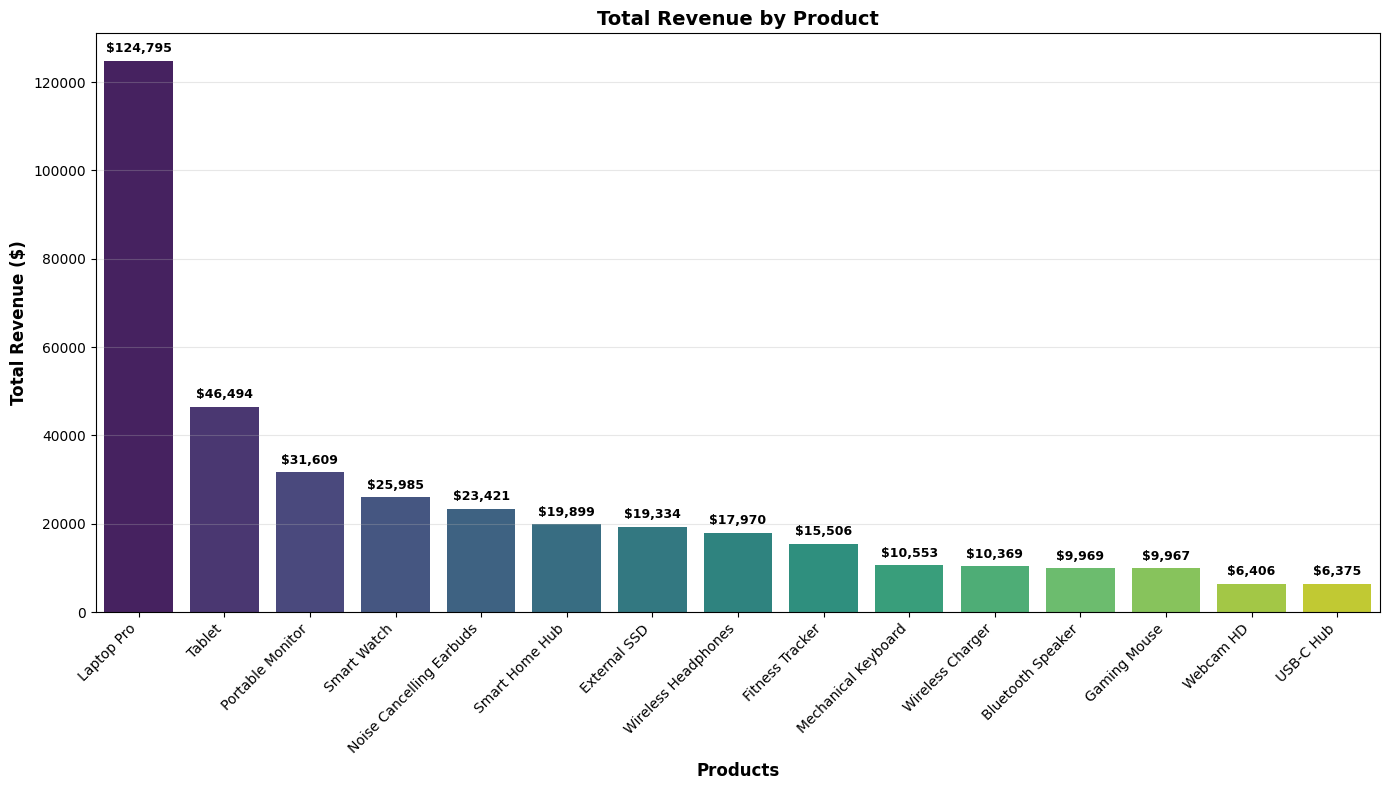

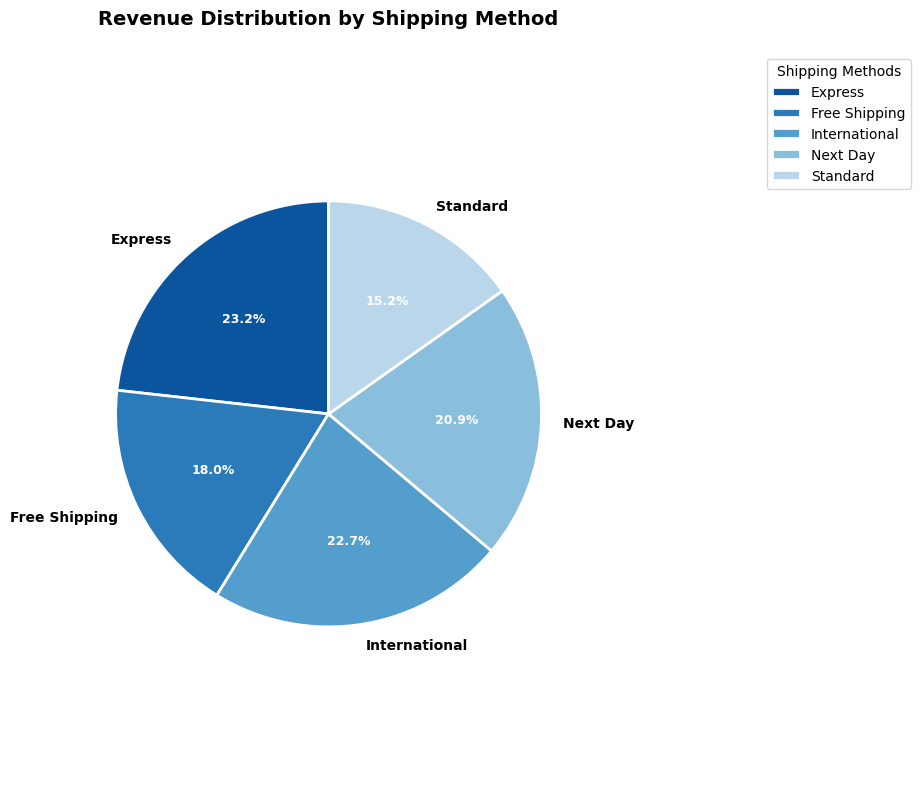

In [16]:
# 8. Plot a bar chart for total revenue by product with perfect x-ticks
plt.figure(figsize=(14, 8))
revenue_by_product = df.groupby('Product')['Total_Price'].sum().sort_values(ascending=False)

# Create the bar plot
ax = sns.barplot(x=revenue_by_product.index, y=revenue_by_product.values, 
                palette='viridis', hue=revenue_by_product.index, legend=False)

plt.xlabel('Products', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Total Revenue by Product', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)

for i, v in enumerate(revenue_by_product.values):
    ax.text(i, v + max(revenue_by_product.values)*0.01, 
            f'${v:,.0f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 9. Plot a pie chart showing distribution of shipping methods with perfect labels
plt.figure(figsize=(10, 8))
revenue_by_shipping = df.groupby('Shipping_Method')['Total_Price'].sum()

wedges, texts, autotexts = plt.pie(revenue_by_shipping.values, 
                                  labels=revenue_by_shipping.index, 
                                  autopct='%1.1f%%', 
                                  startangle=90,
                                  colors=sns.color_palette('Blues_r'),
                                  wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                                  textprops={'fontsize': 10, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.title('Revenue Distribution by Shipping Method', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')

plt.legend(wedges, revenue_by_shipping.index,
          title="Shipping Methods",
          loc="best",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()
